# Grover's Algorithm:
## _An Implementation With Qiskit_

Consider searching for a specific element $x_0$ in a set. Classically, with no additional information, we would simply have to look at the elements of the set one by one until we come across $x_0$. This corresponds to $O(N)$ queries. Grover's algorithm however is able to complete the search in $O(\sqrt{N})$ queries. Grover's algorithm achieves this by repeated use of the _Grover Operator_ $Q$ acting on the uniform superposition state. Each application of this operator 'rotates' the state towards the $|x_0\rangle$ state. The _Grover Operator_ is defined as:
$$Q=-H^{\otimes n}Z_0H^{\otimes n}Z_{x_0}$$
where $H^{\otimes n}$ denotes the product of $n$ Hadamard gates and
$$Z_0 = I - 2|0\rangle\langle 0|$$
$$Z_{x_0} = I - 2|x_0\rangle\langle x_0|$$
The gates $Z_0$ & $Z_{x_0}$ act as phase flips for the states $|0\rangle$ & $|x_0\rangle$ respectively:
$$
Z_0|x\rangle= \begin{cases} -|x\rangle \qquad \text{if }x=0\\
  |x\rangle \qquad \text{if }x≠0
\end{cases}
$$
$$
Z_{x_0}|x\rangle= \begin{cases} -|x\rangle \qquad \text{if }x=x_0\\
  |x\rangle \qquad \text{if }x≠x_0
\end{cases}
$$

Each use of this Grover Operator corresponds to a single query as the information about the target state is encoded in the $Z_{x_0}$ operator.

For a single target state, the optimal number of iterations turns out to be the closest integer to $t=\frac{\pi}{4}\sqrt{N} - \frac{1}{2}$ and hence, the number of queries required by Grover's algorithm is $O(\sqrt{N})$. After this number of iterations, the final state is maximally aligned with $|x_0\rangle$ and hence a measurement of our state will output $x_0$ with high probability.

#### _Aside - Optimal Number of Iterations_
This gets a bit technical, but it's interesting to see where the result comes from rather than just stating it. That being said however, we start with some stated results for the sake of brevity. Let $|\psi_0\rangle$ denote the uniform superposition state:

 - In the plane $P(x_0)$ spanned by $|x_0\rangle$ & $|\psi_0\rangle$, $Q$ acts as a rotation by angle $2\alpha  \in \{0,π\}$ where $\sin(\alpha) = \frac{1}{\sqrt{N}}$.

This means that repeated implementations of $Q$ will rotate the state towards $|x_0\rangle$ whilst remaining in the plane $P(x_0)$.
Now, suppose that the angle (in the plane $P(x_0)$) between $|x_0\rangle$ & $|\psi_0\rangle$ is $\beta$.

Then we have: $$\cos(\beta) = \langle x_0|\psi_0\rangle = \frac{1}{\sqrt{N}} = \sin(\alpha)$$
This means that $\beta  \in \{0,\frac{π}{2}\}$ and we must have $\alpha +\beta = \frac{π}{2}$.

Now, suppose we apply $Q$ a total of $T$ times to $|\psi_0\rangle$ to obtain the state $|\psi_T\rangle$. Let the angle between $|x_0\rangle$ & $|\psi_T\rangle$ be $\delta_T$:
$$ \begin{align}
\delta_T &= \beta - 2\alpha T \\
&= \frac{π}{2} - \alpha - 2\alpha T \\
&= \frac{π}{2} - \alpha(1 + 2T) \\
&= \frac{π}{2} - (1 + 2T)\arcsin(\frac{1}{\sqrt{N}})
\end{align}$$
At the end of the algorithm we measure $|\psi_T\rangle$ and output the result. We want to maximise the probability that the measurement outcome is $x_0$.
$$ \begin{align}
P(\text{outcome is } x_0) &= |\langle x_0|\psi_T\rangle|^2 \\
&= \cos^2(\delta_T) \\
&= \cos^2(\frac{π}{2} - (1 + 2T)\arcsin(\frac{1}{\sqrt{N}})) \\
&= \sin^2((1 + 2T)\arcsin(\frac{1}{\sqrt{N}}))
\end{align}$$

Hence, we want $T$ to be the integer such that $(1 + 2T)\arcsin(\frac{1}{\sqrt{N}})$ is as close as possible to $\frac{π}{2}$.

$$(1 + 2T)\arcsin(\frac{1}{\sqrt{N}}) = \frac{π}{2}$$
$$\Rightarrow T = \frac{π}{4\arcsin(\frac{1}{\sqrt{N}})} - \frac{1}{2}$$

Now using the asymptotic

$$ \arcsin(\frac{1}{\sqrt{N}}) = \frac{1}{\sqrt{N}} + O(\frac{1}{N\sqrt{N}}) \text{ as } N\rightarrow \infty$$

we have the leading order expression for $T$:

$$ T = \frac{π}{4}\sqrt{N} - \frac{1}{2} + O(\frac{1}{N})$$

In practise, choosing the closest integer to the above expression for $T$ means the $O(\frac{1}{N})$ terms really don't matter.


In [1]:
import math
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

We will work on an implementation with 4 qubits. The first thing to do is construct $Q$.

The Hadamard gate is built into Qiskit and so we only need to construct $Z_0$ & $Z_{x_0}$

We can implement $Z_0$ & $Z_{x_0}$ via a multiple control multiple target gate in Qiskit, applying a $Z$ gate controlled by all qubits. This will flip the phase of the state iff all the qubits are in the $|1\rangle$ state

Using this, constructing $Z_0$ is easy, just apply $X$ to each qubit before a multiple control multiple target $Z$ and then $X$ again to each qubit. Below is an example

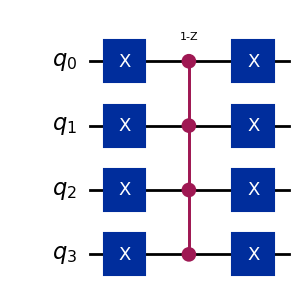

In [25]:
qc = QuantumCircuit(4)
for i in range(4):
    qc.x(i)
qc.compose(MCMTGate(ZGate(), 4 - 1, 1), inplace=True)
for i in range(4):
    qc.x(i)
qc.decompose(reps=0).draw(output="mpl", style="iqp")

For $Z_{x_0}$ we have to consider $x_0$. As we did above, we can simply apply $X$ to any qubit where the corresponding bit in $x_0$ is $0$.

For example, if we're working with 4 qubits and $x_0 = 1110$, our circuit would be:

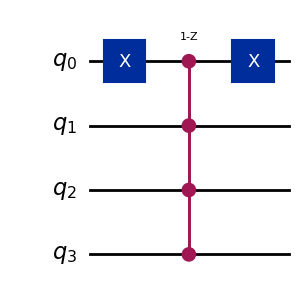

In [4]:
qc = QuantumCircuit(4)
qc.x(0)
qc.compose(MCMTGate(ZGate(), 4 - 1, 1), inplace=True)
qc.x(0)
qc.draw(output="mpl", style="iqp")

For this we need to bear in mind that the $q_0$ qubit corresponds to the least significant bit of $x_0$ and so on. This above circuit flips the phase of the state iff the state of the qubits is $|1110\rangle$

The code below generates $Z_{x_0}$ given general $x_0$, with the example of $x_0 = 1110$ :

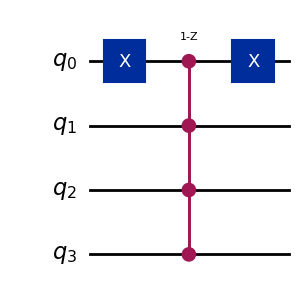

In [72]:
def grover_oracle(x_0):
    num_qubits = len(x_0)
    qc = QuantumCircuit(num_qubits)
    rev_x_0 = x_0[::-1]
    zero_inds = [ind for ind in range(num_qubits) if rev_x_0.startswith("0", ind)]
    qc.x(zero_inds)
    qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    qc.x(zero_inds)
    return qc

x_0 = "1110"
oracle = grover_oracle(x_0)
oracle.draw(output="mpl", style="iqp")

Using this we can now construct the whole Grover Operator $Q$, below is the code generating the Grover Operator given general $x_0$ with the example of $x_0 = 0111$:

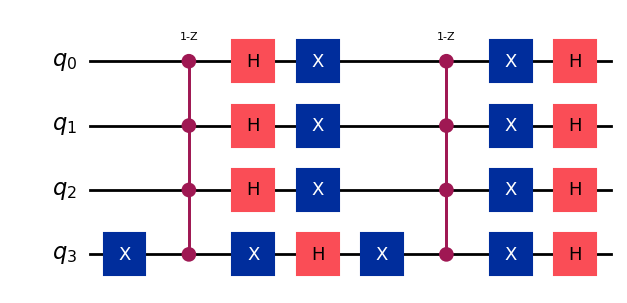

In [74]:
def my_grover_operator(x_0):
    num_qubits = len(x_0)
    qc = QuantumCircuit(num_qubits)
    rev_x_0 = x_0[::-1]
    zero_inds = [ind for ind in range(num_qubits) if rev_x_0.startswith("0", ind)]
    qc.x(zero_inds)
    qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    qc.x(zero_inds)
    qc.h(range(num_qubits))
    qc.x(range(num_qubits))
    qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    qc.x(range(num_qubits))
    qc.h(range(num_qubits))
    return qc

x_0 = '0111'
Q = grover_operator(x_0)
Q.draw(output="mpl", style="iqp")

Now we have $Q$ we can construct the circuit implementing Grover's Algorithm.

We will need to determine the optimal number of iterations to use. In the case of 4 qubits corresponding to $2^4 = 16$ elements, this optimal number is 3.

Below is the code generating the whole Grover circuit for $x_0 = 1010$, including the initial set up of the uniform superposition state. Note the three applications of the Grover operator in the circuit diagram below:

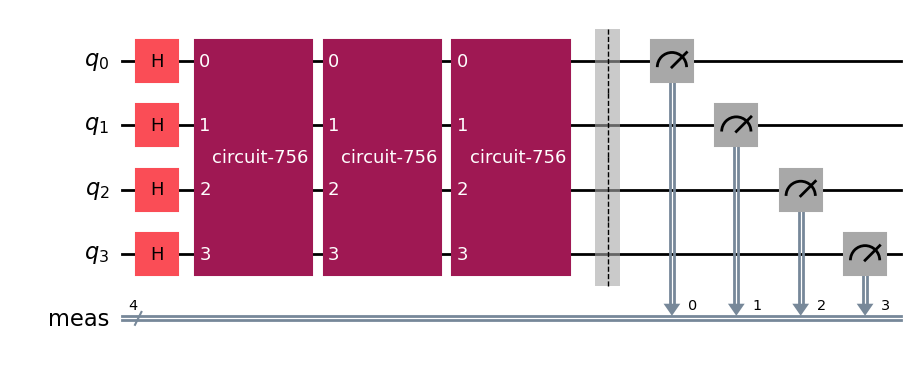

In [78]:
def grover_circuit(x_0):
    num_qubits = len(x_0)
    qc = QuantumCircuit(num_qubits)
    optimal_iter = round((math.pi*math.sqrt(2**num_qubits)/4) - 0.5)
    qc.h(range(num_qubits))
    qc.compose(my_grover_operator(x_0).power(optimal_iter), inplace=True)
    qc.measure_all()
    return qc

x_0 = "1010"
qc = grover_circuit(x_0)
qc.draw(output="mpl", style="iqp")

Now we are ready to run this circuit on IBM hardware, in this case we use IBM Marrakesh. Below is the code used and a graph illustrating the results from 10,000 runs. As we can see, the target state stands out significantly as the most common output state.

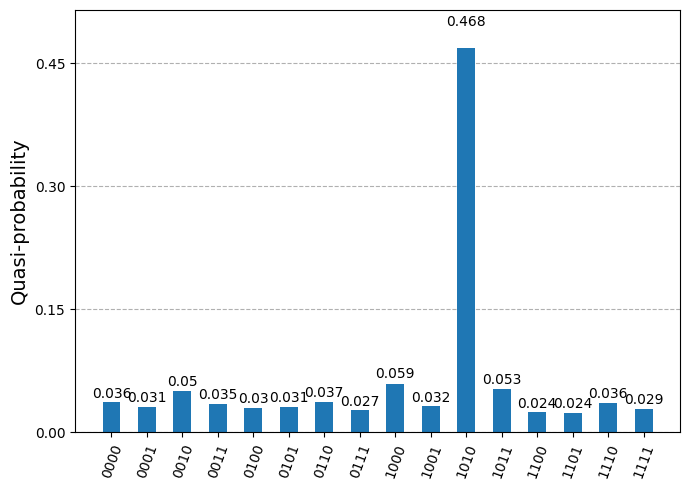

In [70]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

service = QiskitRuntimeService()
backend = service.backend("ibm_marrakesh")
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_isa = pm.run(qc)
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10_000
result = sampler.run([qc_isa]).result()
dist = result[0].data.meas.get_counts()
plot_distribution(dist)